# ASR Simulation 2: Grid 2 (10ft near well) with Chemistry from Phreeqc Example 11 

This simulation adds **cation exhange reaction chemistry** -- from the PHREEQC-3 Manual's Example 11 (Parkhurst and Appelo 2013) -- to the 3D transport models of the simple ASR test case.

For information and exploration of the simple ASR Modflow 6 simulation used throughout this repository, see `sims/sim00-mf6only/mf6_explore.ipynb`.

The workflow for this example:
- Read geochemical components and their initial and boundary concentrations from PHREEQC input files
- Create new Modflow 6 transport model for each aqueous phase (components in the Solution blocks) and add their initial concentrations over the entire DISV grid.
- Modify the Modflow 6 Flow Well package Stress Period Data (SPD) by adding Solution component concentrations.
- Run the modified Modflow 6 for conservative transport of all components (i.e. no coupling to PHREEQC)
- Run the coupled Modflow 6 & PHREEQC models for the entire simulation

NOTE: This [Jupytext](https://jupytext.readthedocs.io/en/latest/index.html) paired notebook, with paired `.py` and `.ipynb` files. 
- If using VS Code, install the the [Jupytext Sync extension](https://jupytext.readthedocs.io/en/latest/vs-code.html) for maximum benefit.

# Installation and Setup

Create a custom conda virtual environment can be created using the `environment.yml` file included in this repo. 

Complet the setup by running the `01-GettingStarted.ipynb` notebook.

## Python Imports

In [1]:
import os
import shutil
from pathlib import Path
from importlib.metadata import version
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import flopy
from modflowapi import ModflowApi

In [2]:
# Import the MFRTM package, installed using `conda develop`
import mf6rtm
version("mf6rtm")

'0.3.2.dev0'

In [3]:
from mf6rtm_asr_example import utils # from this repo

### If you get `ModuleNotFoundError`

Run the `01-GettingStarted.ipynb` notebook to install `mf6rtm` using `conda develop`.

## Set Paths to Input and Output Files with `pathlib`

Use the [pathlib](https://docs.python.org/3/library/pathlib.html) library 
(built-in to Python 3) to manage paths indpendentely of OS or environment. 
See this [blog post]
(https://medium.com/@ageitgey/python-3-quick-tip-the-easy-way-to-deal-with-file-paths-on-windows-mac-and-linux-11a072b58d5f) 
to learn about the many benefits over using the `os` library.

In [4]:
# user = "Laren"
user = "Anthony"

In [5]:
# Find your current working directory, which should be folder for this notebook.
working_dir = Path.cwd()
# Find repository path (i.e. the parent to `/examples` directory for this notebook)
repo_path = working_dir.parent.parent
repo_path
if user == "Laren":
    repo_path = Path("C:\\Users\\rdchllkm\\Documents\\GitHub\\mf6rtm-asr-example")
    working_dir = repo_path / "sims" / "sim02-ex11"

In [6]:
simulation_name = working_dir.name
simulation_name

'sim02-ex11'

In [7]:
# Path to simulation workspace, which is git-ignored and 
# will get over-written with each run of this notebook
sim_ws = working_dir / 'ws2' # Grid 2
sim_ws.mkdir(parents=True, exist_ok=True)

### Reset Workspace

In [8]:
# Delete previous contents from simulation
if sim_ws.exists():
    try:
        shutil.rmtree(sim_ws)
        print(f"Directory '{sim_ws}' and its contents removed successfully.")
        sim_ws.mkdir(parents=True, exist_ok=True)
    except OSError as e:
        print(f"Error: {sim_ws} : {e.strerror}")
else:
    print(f"Directory '{sim_ws}' does not exist.")

Directory '/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm-asr-example/sims/sim02-ex11/ws2' and its contents removed successfully.


### Modflow Inputs

In [9]:
# Modflow inputs file folder
# Grid 2 = 10ft resolution near well (vs 2ft for original)
mf6_inputs_path = repo_path / 'data' / 'MF6_ASR_DISV_inputs2' # Grid 2

In [10]:
# Copy input files to simulation workspace directory)
shutil.copytree(mf6_inputs_path, sim_ws, dirs_exist_ok=True)

PosixPath('/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm-asr-example/sims/sim02-ex11/ws2')

In [11]:
# Add required empty output folders
folders = [
    'flow_output',
    'trans-TDS_output',
    'trans-temp_output',
]
for folder in folders:
    path = sim_ws / folder
    path.mkdir(parents=True, exist_ok=True)

In [12]:
# Set filepath for the MF6 simulation configuration file
sim_nam_file_path = sim_ws / "mfsim.nam"
assert sim_nam_file_path.exists()
sim_nam_file_path

PosixPath('/Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm-asr-example/sims/sim02-ex11/ws2/mfsim.nam')

In [13]:
# Set modflow input path equal to simulation workspace
mf6_input_path = sim_ws

### PHREEQC Inputs

In [14]:
# Phreeqc input file folder
chem_inputs_path = working_dir / "chem_inputs"
chem_input_files = os.listdir(chem_inputs_path)
chem_input_files

['chem_exchanges.csv',
 'chem_postfix.phqr',
 'chem_ex11.pqi',
 'chem_solutions.csv']

In [15]:
# Copy input files to simulation workspace directory (i.e. project path)
for file in chem_input_files:
    shutil.copy2(chem_inputs_path / file, sim_ws)

In [16]:
# Path to PHREEQC Block Input CSV Files
solutions_filepath = sim_ws / "chem_solutions.csv"
exchanges_filepath = sim_ws / "chem_exchanges.csv"
assert solutions_filepath.exists() and exchanges_filepath.exists()

In [17]:
# Path to file with PHREEQC Input "postfix" instructions
# to be appended to the PHREEQC Input file (*.pqi) created by mf6rtm
postfix_filepath = sim_ws /  'chem_postfix.phqr'
assert postfix_filepath.exists()

In [18]:
# Select PHREEQC database file
# phreeqc_database_file = "phreeqc.dat" # used in Ex6?
phreeqc_database_file = 'pht3d_datab.dat' # used in Ex4
phreeqc_databases_path = repo_path / "data" / "chem_databases"
phreeqc_database_filepath = phreeqc_databases_path / phreeqc_database_file
assert phreeqc_database_filepath.exists(), "PHREEQC database file missing"

In [19]:
# Paths to PHREEQC configuration files that will be created by mf6trm
# PHREEQC Input file (*.pqi)
phreeqc_input_filepath = sim_ws / "phinp.dat"
# PhreeqcRM YAML config file
phreeqcrm_yaml_filepath = sim_ws / "mf6rtm.yaml"
print("MF6RTM-created PHREEQCRM YAML file exists?", phreeqcrm_yaml_filepath.exists())

MF6RTM-created PHREEQCRM YAML file exists? False


## Set Path to MF6 Executable & Library
Different versions can be downloaded from: https://github.com/MODFLOW-ORG/executables to a folder similar to this: `bin/mf6.5.0/macarm` 

On Mac, will need to give permissions with these terminal commands from the 
```sh
xattr -dr com.apple.quarantine mf6
xattr -dr com.apple.quarantine libmf6.dylib
```


In [20]:
use_version_installed_with_modflowapi = True
# user = "Laren"
user = "Anthony"
os = "macarm"

# version = "6.4.2"
# version = "6.5.0"
version = "6.7.0"

try:
    mf6_exe = Path(flopy.which("mf6"))
    dll = mf6_exe.parent.parent / "lib" / "libmf6.dylib" # MacOS only for now
    mf6_version = !{mf6_exe} --version
    mf6dll_version = ModflowApi(dll).get_version()
    print(f"Executable & library installed with modflowapi: {mf6_version[1]}, dll: {mf6dll_version}")
except Exception:
    print("Modflow executables not found in environment")

if use_version_installed_with_modflowapi:
    print(f"Using executable installed with modflowapi: {mf6_version[1]}")
else:
    if user == "Lauren":
        # If using executable from GMS
        mf6_bin_path = Path(r"C:/program files/gms 10.8 64-bit/python/lib/site-packages/xms/executables/modflow6")
        mf6_exe = mf6_bin_path / "mf6.exe"
        dll = mf6_bin_path / "libmf6.dll"
    elif user == "Anthony":
        mf6_potential_paths = [
            repo_path / "bin" / f"mf{version}" / os,
            repo_path / "bin" / f"mf{version}_{os}" / "bin",
        ]
        for path in mf6_potential_paths:
            if path.exists():
                mf6_bin_path = path
        mf6_exe = mf6_bin_path / "mf6"
        dll = mf6_bin_path / "libmf6.dylib"
    else:
        print("Create a new user and set paths to mf6 and libmf6")
    mf6_version = !{mf6_exe} --version
    mf6dll_version = ModflowApi(dll).get_version()
    print(f"User-selected executable ({mf6_exe.exists()}): {mf6_version[1]}, dll: {mf6dll_version}")

Executable & library installed with modflowapi: mf6: 6.7.0 02/06/2026, dll: 6.7.0
Using executable installed with modflowapi: mf6: 6.7.0 02/06/2026


In [21]:
# Copy executable and library to simulation workspace
shutil.copy2(mf6_exe, sim_ws)
shutil.copy2(dll, sim_ws)
(sim_ws/mf6_exe.name).exists()

True

# Load Modflow 6 Simulation for Reactive Transport
To set up PhreeqcRM and MF6RTM simulation objects.
Modifies Modflow 6 input files to include transport models for all reactive transport species.

For addtional information and exploration of the simple ASR Modflow 6 simulation used throughout this repository, see `sims/sim00-mf6only/mf6_explore.ipynb`

In [22]:
# Load simulation using Flopy
sim = flopy.mf6.MFSimulation.load(
    sim_ws=sim_ws,
    exe_name=mf6_exe,  #'mf6',
    verbosity_level=0,
)
sim.model_names

['flow', 'trans-tds', 'trans-temp']

## Modify Flow Model

In [23]:
# load existing gwf model
for model_name in sim.model_names:
    model = sim.get_model(model_name)
    if model.model_type == "gwf6":
        gwf = model

# removes buy package from gwf model
gwf.remove_package("buy")
gwf.get_package_list()

['DISV', 'NPF', 'IC', 'OC', 'STO', 'WEL', 'CHD', 'GHB']

In [24]:
# modify output control package to not print head to .lst file
oc = gwf.get_package("oc")
print_record = oc.printrecord.get_data()
print_rec = print_record[0]
mask = ~(
    (print_rec.rtype == "head")
    & (print_rec.ocsetting == "all")
    & (print_rec.ocsetting_data == None)
)
print_record_new = {}
print_record_new[0] = print_record[0][mask]
oc.printrecord.set_data(print_record_new)

In [25]:
# modify npf package to save specific discharge
npf = gwf.get_package("npf")
npf.save_specific_discharge = True

## Read Grid Info

In [26]:
# Get groundwater model names and grid info
for model_name in sim.model_names:
    # Collect model info 
    model = sim.get_model(model_name)
    model_type = model.model_type
    grid_type = model.get_grid_type()
    grid_units = model.modelgrid.units
    # Collect grid information
    grid_package = model.get_package(grid_type.name)
    nlay = grid_package.nlay.get_data()  # number of layers
    ncpl = grid_package.ncpl.get_data()  # number of cells per layer
    print(f"{model_name}: ", model_type, grid_type.name, grid_units, nlay, ncpl)

flow:  gwf6 DISV feet 5 957
trans-tds:  gwt6 DISV feet 5 957
trans-temp:  gwt6 DISV feet 5 957


In [27]:
# Use spatial discretization info from the last model
# Calculate total number of grid cells
nxyz = nlay * ncpl
nxyz

4785

In [28]:
# lookup cell ID of wel package cell
# NOTE: indices from flopy use Python indexing from 0
wel_spd = gwf.wel.stress_period_data.array
wel_cellid = wel_spd[0]["cellid"][0]
display(wel_cellid)

wel_lay = wel_cellid[0]
wel_cellnum = wel_cellid[1]

(2, 462)

### Cell Spacing

In [29]:
grid_package.length_units

{internal}
('feet')

In [30]:
celldata = grid_package.cell2d.get_data()
# data stored in numpy record arrays  
# can be easily converted to pandas dataframes
cells_df = pd.DataFrame.from_records(celldata, index='icell2d')
cells_df

,xc,yc,ncvert,icvert_0,icvert_1,icvert_2,icvert_3,icvert_4,icvert_5
icell2d,,,,,,,,,
0,694376.127565,1.027689e+06,4,3,2,1,0,None,None
1,694530.764694,1.027689e+06,4,5,4,2,3,None,None
2,694685.401823,1.027689e+06,4,7,6,4,5,None,None
3,694840.038952,1.027689e+06,4,9,8,6,7,None,None
4,694994.676081,1.027689e+06,4,11,10,8,9,None,None
...,...,...,...,...,...,...,...,...,...
952,698396.692919,1.023169e+06,4,993,1025,1024,992,None,None
953,698551.330048,1.023169e+06,4,994,1026,1025,993,None,None
954,698705.967177,1.023169e+06,4,995,1027,1026,994,None,None


### Cell Volumes

In [31]:
### Calculate grid cell volume
cell2D = grid_package.cell2d.get_data()
cell2D_df = pd.DataFrame.from_records(cell2D, index='icell2d')
vertices = grid_package.vertices.get_data()
vertices_df = pd.DataFrame.from_records(vertices, index='iv')
top = grid_package.top.array
botm = grid_package.botm.array

### Calculate surface area of each grid cell within a single layer
for cell in range(len(cell2D_df)):
    ### get vertice coordinates to calc surface area
    temp_cell_info = cell2D_df.iloc[[cell]]
    # read each vert_1 - 5
    icverts = temp_cell_info.filter(like="icvert_").iloc[0].to_list()
    # remove Nones
    icverts_clean = [int(v) for v in icverts if v is not None]
    # look up (x,y) and create x and y arrays
    x_l = vertices_df.loc[icverts_clean,"xv"].to_numpy()
    y_l = vertices_df.loc[icverts_clean,"yv"].to_numpy()
    # calculate surface area based on min/max x/y from array
    surface_area = (np.max(x_l)-np.min(x_l)) * (np.max(y_l) - np.min(y_l))
    cell2D_df.loc[cell,'surface_area'] = surface_area

### Calc layer thickness for each layer
# initialize thickness array
thickness = np.zeros_like(botm)
# for layer 1:
thickness[0] = top - botm[0]
# for layers 2:nlay
thickness[1:] = botm[:-1] - botm[1:]

### Calculate volume for each grid cell
# initialize volume array
cell_volumes = np.zeros((nlay,ncpl))
# calculate volume for entire grid
for k in range(nlay):
    cell_volumes[k,:] = cell2D_df['surface_area'].to_numpy() * thickness[k,:]

In [32]:
# volume of cells near well screen
cell_volumes[2, wel_cellnum-6:wel_cellnum+6]

array([ 352455.27301523,  352455.27301523,  352455.27301524,
        352455.27301418,   88113.81825434,   88113.81825381,
         88113.81825434,   88113.81825381,  352455.27301523,
       1409821.09205884, 1409821.09205884, 1409821.09206095])

In [33]:
# TODO: Get flat Cell Index to (cellid_layer, cellid_cell) mapping
# for exploring phreeqcrm outputs

## Read Time Info

### Time Steps

In [34]:
# Get time discretization info from the `tdis` package
tdis = sim.tdis
nper = tdis.nper.get_data()          # number of stress periods
perioddata = tdis.perioddata.get_data() # record array
nstp = perioddata['nstp']            # number of timesteps per stress period
perlen = perioddata['perlen']        # length of stress periods
tsmult = perioddata['tsmult']        # timestep multiplier
t_units = tdis.time_units.get_data() # units

print(f'{nper} stress periods. Units: {t_units}')
perioddata

21 stress periods. Units: days


rec.array([( 1., 1, 1.), (13., 2, 1.), (28., 3, 1.), (31., 3, 1.),
           (30., 3, 1.), (31., 3, 1.), (30., 3, 1.), ( 9., 1, 1.),
           (22., 2, 1.), (31., 3, 1.), (30., 3, 1.), (31., 3, 1.),
           (30., 3, 1.), (31., 3, 1.), ( 3., 1, 1.), (28., 3, 1.),
           (28., 3, 1.), (31., 3, 1.), (30., 3, 1.), (31., 3, 1.),
           (16., 2, 1.)],
          dtype=[('perlen', '<f8'), ('nstp', '<i8'), ('tsmult', '<f8')])

In [35]:
pd.DataFrame.from_records(perioddata)

,perlen,nstp,tsmult
0,1.0,1,1.0
1,13.0,2,1.0
2,28.0,3,1.0
3,31.0,3,1.0
4,30.0,3,1.0
5,31.0,3,1.0
6,30.0,3,1.0
7,9.0,1,1.0
8,22.0,2,1.0
9,31.0,3,1.0


### Stress Period Data

In [36]:
# boundary conditions for chem_stress
# get boundary condition packages with transport
# read in spd stress period data ... which varries based on package...

# for well package (wel):
wel = gwf.get_package('wel')
if wel.has_stress_period_data == True:
    spd_wel_dict = wel.stress_period_data.get_data(full_data=True) # full data is default
display(spd_wel_dict)

{0: rec.array([((2, 462), 0, 0.00429, 25, 0., 'krasr')],
           dtype=[('cellid', 'O'), ('q', '<i8'), ('tds', '<f8'), ('temp', '<i8'), ('cellgrp', '<f8'), ('boundname', 'O')]),
 1: rec.array([((2, 462), 668359.8449, 0.00429, 25, 0., 'krasr')],
           dtype=[('cellid', 'O'), ('q', '<f8'), ('tds', '<f8'), ('temp', '<i8'), ('cellgrp', '<f8'), ('boundname', 'O')]),
 2: rec.array([((2, 462), 668359.8449, 0.00429, 25, 0., 'krasr')],
           dtype=[('cellid', 'O'), ('q', '<f8'), ('tds', '<f8'), ('temp', '<i8'), ('cellgrp', '<f8'), ('boundname', 'O')]),
 3: rec.array([((2, 462), 668359.8449, 0.00429, 25, 0., 'krasr')],
           dtype=[('cellid', 'O'), ('q', '<f8'), ('tds', '<f8'), ('temp', '<i8'), ('cellgrp', '<f8'), ('boundname', 'O')]),
 4: rec.array([((2, 462), 668359.8449, 0.00429, 25, 0., 'krasr')],
           dtype=[('cellid', 'O'), ('q', '<f8'), ('tds', '<f8'), ('temp', '<i8'), ('cellgrp', '<f8'), ('boundname', 'O')]),
 5: rec.array([((2, 462), 668359.8449, 0.00429, 25, 0.,

In [37]:

# data stored in a dictionary of numpy record arrays
# which allows easy concatination into a single dataframe, using
# flopy dataframe interface that includes auxilary data (i.e. components) when present
spd_wel_df_dict = wel.stress_period_data.dataframe
spd_wel_df = pd.concat(spd_wel_df_dict.values(), keys=spd_wel_df_dict.keys())
spd_wel_df = spd_wel_df.droplevel(level=1)
# spd_wel_df.index.set_names(['stress_period_id'], inplace=True)
spd_wel_df.info()
spd_wel_df

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 0 to 20
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cellid_layer  21 non-null     int64  
 1   cellid_cell   21 non-null     int64  
 2   q             21 non-null     float64
 3   tds           21 non-null     float64
 4   temp          21 non-null     int64  
 5   cellgrp       21 non-null     float64
 6   boundname     21 non-null     object 
dtypes: float64(3), int64(3), object(1)
memory usage: 1.3+ KB


,cellid_layer,cellid_cell,q,tds,temp,cellgrp,boundname
0,2,462,0.000000,0.00429,25,0.0,krasr
1,2,462,668359.844900,0.00429,25,0.0,krasr
2,2,462,668359.844900,0.00429,25,0.0,krasr
3,2,462,668359.844900,0.00429,25,0.0,krasr
4,2,462,668359.844900,0.00429,25,0.0,krasr
5,2,462,668359.844900,0.00429,25,0.0,krasr
6,2,462,668359.844900,0.00429,25,0.0,krasr
7,2,462,668359.415142,0.00429,25,0.0,krasr
8,2,462,0.000000,0.00429,25,0.0,krasr
9,2,462,0.000000,0.00429,25,0.0,krasr


NOTE: `cellid` is a cell identifier tuple, and depends on the type of grid that is used for the simulation. 
- For a structured grid that uses the DIS input file, CELLID is the layer, row, and column. 
- For a grid that uses the DISV input file, CELLID is the layer and CELL2D number. 
- If the model uses the unstructured discretization (DISU) input file, CELLID is the node number for the cell.

# Get Geochemistry for Transport Models and their Initial Conditions

This first step is to create MF6 Groundwater Transport Models (GWT) for each transportable geochemical component, including setting initial conditions (IC).

This requires running an initial PHREEQC calculation from measured inputs, using utilities from the [`mf6rtm`](https://github.com/p-ortega/mf6rtm) package. 

Our workflow, similar to [`mf6rtm` example 4](https://github.com/p-ortega/mf6rtm/blob/main/benchmark/ex4.ipynb), requires these steps:
- read inputs by PHREEQC "keyword data blocks"
- convert to a dictionary
- instantiate `mup3d.{Block}` classes that contain the block's geochemical components
- set the grid size/shape for the components

### SOLUTION Block
See PHREEQC3 Manual, page 189

In [38]:
# Read Geochemical Inputs file
# for aqueous phase ("solution") components
solutions_df = pd.read_csv(solutions_filepath, index_col="component")
solutions_df

,solution1_ic_molperL,solution2_bc_molperL
component,,
pH,7.0000,7.0000
pe,12.5000,12.5000
Ca,0.0000,0.0006
Cl,0.0000,0.0012
K,0.0002,0.0000
Na,0.0010,0.0000
N(+5),0.0012,0.0000


In [39]:
# convert dataframe to a Keyword Data Block dictionary
# NOTE: `mf6rtm.mup3D()` currently assigns block numbers by column, starting at 1
solutions_dict = mf6rtm.utils.solution_df_to_dict(solutions_df)

# add data to the mup3d class
solutions = mf6rtm.mup3d.Solutions(solutions_dict)
solutions.data

{'pH': [7.0, 7.0],
 'pe': [12.5, 12.5],
 'Ca': [0.0, 0.0006],
 'Cl': [0.0, 0.0012],
 'K': [0.0002, 0.0],
 'Na': [0.001, 0.0],
 'N(+5)': [0.0012, 0.0]}

In [40]:
solutions.names

['Ca', 'Cl', 'K', 'N(+5)', 'Na', 'pH', 'pe']

#### Assign SOLUTION Initial Conditions (IC) to all Grid Cells by Block Number

In [41]:
# mup3d currently requires a grid array with 3 dimensions
""" conc[0].shape = 
        (240, 2, 1, 80)
        ^     ^  ^  ^
        |     |  |  number of cells per layer (ncpl)
        |     |  dummy row dimension (always 1 for DISV)
        |     number of layers (nlay = 2)
        number of time steps (240)"""
# So assign dummy dimensions
nrow = 1
ncol = ncpl # should equal ncpl, but simplifying for now

In [42]:
# Assign solution block numbers to each in grid
# NOTE: at this stage of creating modflow transport models (gwt), we only want one cell per block

# start by assigning solution block 1 to all cells
grid_ic_solution_numbers = np.ones((nlay, 1, ncpl), dtype=int)

# Modify block assignments over grid, as needed

solutions.set_ic(grid_ic_solution_numbers)
solutions.ic

array([[[1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1]]], shape=(5, 1, 957))

#### Assign SOLUTION Boundary Conditions (BC) to Grid Perimeter
Using the Mup3D.ChemStress class to assign Stress Period Data (SPD)

In [43]:
# Create a chd chemistry object
chdchem = mf6rtm.mup3d.ChemStress('chd')
chd_sol_spd = [1] # use same solution as inital conditions
# Assign solution block number to stress period data for chd
chdchem.set_spd(chd_sol_spd)
chdchem.sol_spd

[1]

In [44]:
# Create a ghb chemistry object
ghbchem = mf6rtm.mup3d.ChemStress('ghb')
ghb_sol_spd = [1] # use same solution as inital conditions
# Assign solution block number to stress period data for chd
ghbchem.set_spd(ghb_sol_spd)
ghbchem.sol_spd

[1]

#### Assign SOLUTION Boundary Conditions (BC) to all Inflows by Block Number
Using the Mup3D.ChemStress class to assign Stress Period Data (SPD)

In [45]:
# Create a well chemistry object
wellchem = mf6rtm.mup3d.ChemStress('wel')

# Assign solution block number to stress period data (spd)
# TODO: implement for multiple wells?
sol_spd = [2] 
wellchem.set_spd(sol_spd)
wellchem.sol_spd

[2]

In [46]:
# Confirm that stress period data (spd) is properly assigned
for data_column_number in wellchem.sol_spd:
     solutions_list_index = data_column_number - 1
     for key, value in solutions.data.items():
        print(key, value[solutions_list_index])

pH 7.0
pe 12.5
Ca 0.0006
Cl 0.0012
K 0.0
Na 0.0
N(+5) 0.0


### EXCHANGE Block

See PHREEQC3 Manual, page 189

In [47]:
# Read Geochemical Inputs file for exchange phase components
exchange_df = pd.read_csv(exchanges_filepath, index_col="component")
exchange_df

,m0
component,
CaX2,0.000000
NaX,0.000549
KX,0.000551


In [48]:
# convert dataframe to a Keyword Data Block dictionary
exchange_dict = {0:exchange_df.T.to_dict(index='component')}

# add data to the mup3d class
exchanger = mf6rtm.mup3d.ExchangePhases(exchange_dict)
exchanger.data

{0: {'CaX2': {'m0': 0.0}, 'NaX': {'m0': 0.0005493}, 'KX': {'m0': 0.0005507}}}

In [49]:
exchanger.names

['CaX2', 'KX', 'NaX']

#### Assign EXHANGE Initial Conditions (IC) to all Grid Cells by Block Number

In [50]:
# Set Solution Block Number for equilibration
# TODO: eliminate need for this by equilibrating to solutions blocks specied over the IC grid
exchanger.set_equilibrate_solutions([1])

# Assign block numbers to each cell
# NOTE: at this stage of creating modflow transport models (gwt), we only want one cell per block
# start by assigning exchange block 0 to all cells
grid_ic_exchange_numbers = np.ones((nlay, 1, ncpl), dtype=int)

exchanger.set_ic(grid_ic_exchange_numbers)

In [51]:
exchanger.ic

array([[[1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1]]], shape=(5, 1, 957))

### Create a reaction model (RM) instance using the `mf6rtm` `Mup3d` class

In [52]:
# create model class, with solution initial conditions
reaction_model = mf6rtm.mup3d.Mup3d(simulation_name, solutions, nlay, nrow, ncol)

# set model workspace for saving outputs
reaction_model.set_wd(sim_ws)

# set Phreeqc database
reaction_model.set_database(phreeqc_database_filepath)

# set exchange phases
reaction_model.set_exchange_phases(exchanger)

# set Phreeqc postfix file
reaction_model.set_postfix(postfix_filepath)

print(reaction_model.name, reaction_model.grid_shape)

sim02-ex11 (5, 1, 957)


In [53]:
reaction_model.solutions.data

{'pH': [7.0, 7.0],
 'pe': [12.5, 12.5],
 'Ca': [0.0, 0.0006],
 'Cl': [0.0, 0.0012],
 'K': [0.0002, 0.0],
 'Na': [0.001, 0.0],
 'N(+5)': [0.0012, 0.0]}

In [54]:
reaction_model.exchange_phases.data

{0: {'CaX2': {'m0': 0.0}, 'NaX': {'m0': 0.0005493}, 'KX': {'m0': 0.0005507}}}

### Set Component H2O to transport excess H & O

[`SetComponentH2O()`](https://usgs-coupled.github.io/phreeqcrm/namespacebmiphreeqcrm.html#a0e152e5b6933e3e6bd8c79245917639a) is a PhreeqcRM function to select whether to include H2O in the component list. 
- The concentrations of H and O must be known accurately (8 to 10 significant digits) for the numerical method of PHREEQC to produce accurate pH and pe values. 
- Because most of the H and O are in the water species, it may be more robust (require less accuracy in transport) to transport the excess H and O (the H and O not in water) and water. 
- The default setting (true) is to include water, excess H, and excess O as components. 
- A setting of false will include total H and total O as components. 
- `SetComponentH2O` must be called before `FindComponents`. 

NOTE: The default for `mf6rtm` is FALSE, to use total H & O as components.

In [55]:
reaction_model.set_componenth2o(True) # True = transport H20 and excess H & O

True

### Initialize IC Chemistry over Model Grid 
This creates a PhreeqcRM instance based on components in Solution Blocks assigned initial conditions over the grid. It then runs a PHREEQC time zero equilibrium calculation for inital speciation.

In [56]:
# Intializing the mup3d class calculates the equilibrated
# initial concentration array
# NOTE: It appears that nthreads cannot be increased above 1 if using the Python phreeqcrm package
# See https://github.com/p-ortega/mf6rtm/issues/54

reaction_model.initialize(
    nthreads=4, 
    add_charge_flag=True,
)
# NOTE: If this hangs, check all input files for "!" 

Using temperatue of 25.0 for all cells


          Estimated efficiency of chemistry without communication: 99.5772
          Cells shifted between threads     0
          Time rebalancing load             7.9155e-05


MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: all
  External files flag: False
  Emulator flag: False
  Reactions calculated at all time steps
Simulation saved in /Users/aaufdenkampe/Documents/git_mf6rtm/mf6rtm-asr-example/sims/sim02-ex11/ws2
Phreeqc initialized


In [57]:
reaction_model.phreeqc_rm.GetThreadCount()

4

In [58]:
# Dictionary of solution concentrations in units of moles per m^3 (or mmol/L), 
# and structured to match the shape of Modflow's grid
reaction_model.sconc  # comment out to reduce outputs
reaction_model.sconc['Charge'][wel_lay,:,wel_cellnum]  # or use it to find value at a single cell

array([-8.71680812e-14])

In [59]:
reaction_model.components

['H2O', 'H', 'O', 'Charge', 'Ca', 'Cl', 'K', 'N', 'Na']

In [60]:
# 1D array of concentrations in units of mol/L 
# structured for PhreeqcRM `GetConcentrations()` and BMI with
# component concentratinon arrays for the grid ordered as `model.components`
# Equivalent to `c_dbl_vect` (concentration double vector) in mf6rtm source code
reaction_model.init_conc_array_phreeqc

array([5.53420855e+01, 5.53420855e+01, 5.53420855e+01, ...,
       9.97039824e-04, 9.97039824e-04, 9.97039824e-04], shape=(43065,))

In [61]:
# Get component concentrations for selected grid cell
cell_index = 0
ncomps_by_nxyz_conc_array = np.reshape(
    reaction_model.init_conc_array_phreeqc, 
    (len(reaction_model.components), -1),
)
ncomps_by_nxyz_conc_array[:,cell_index]

array([ 5.53420855e+01,  2.08742065e-07,  3.58947343e-03, -8.71680812e-17,
        0.00000000e+00,  0.00000000e+00,  1.99407284e-04,  1.19645161e-03,
        9.97039824e-04])

In [62]:
# Get component concentrations for a selected grid cell
# converting to units of moles per m^3 (or mmol/L) for modflow
cell_index = 0
ic_df = pd.DataFrame(
    ncomps_by_nxyz_conc_array[:,cell_index] * 1000, # unit conversion
    index=reaction_model.components,
    columns=["initial_conc_mmolL"],
)
ic_df.index.rename("components", inplace=True)
ic_df.index = ic_df.index.astype(pd.CategoricalDtype(ordered=True))
ic_df

,initial_conc_mmolL
components,
H2O,5.534209e+04
H,2.087421e-04
O,3.589473e+00
Charge,-8.716808e-14
Ca,0.000000e+00
Cl,0.000000e+00
K,1.994073e-01
N,1.196452e+00
Na,9.970398e-01


In [63]:
# Dictionary of concentrations in units of moles per m^3 (or mmol/L), 
# and structured to match the shape of Modflow's grid
reaction_model.sconc

{'H2O': array([[[55342.08546994, 55342.08546994, 55342.08546994, ...,
          55342.08546994, 55342.08546994, 55342.08546994]],
 
        [[55342.08546994, 55342.08546994, 55342.08546994, ...,
          55342.08546994, 55342.08546994, 55342.08546994]],
 
        [[55342.08546994, 55342.08546994, 55342.08546994, ...,
          55342.08546994, 55342.08546994, 55342.08546994]],
 
        [[55342.08546994, 55342.08546994, 55342.08546994, ...,
          55342.08546994, 55342.08546994, 55342.08546994]],
 
        [[55342.08546994, 55342.08546994, 55342.08546994, ...,
          55342.08546994, 55342.08546994, 55342.08546994]]],
       shape=(5, 1, 957)),
 'H': array([[[0.00020874, 0.00020874, 0.00020874, ..., 0.00020874,
          0.00020874, 0.00020874]],
 
        [[0.00020874, 0.00020874, 0.00020874, ..., 0.00020874,
          0.00020874, 0.00020874]],
 
        [[0.00020874, 0.00020874, 0.00020874, ..., 0.00020874,
          0.00020874, 0.00020874]],
 
        [[0.00020874, 0.00020874, 

#### Aside to test approaches for reshaping

In [64]:
# create alias for testing current implementation
# `c_dbl_vect` is the concentration double vector in units of mol/L
c_dbl_vect = reaction_model.init_conc_array_phreeqc

In [65]:
# %%timeit
# # Current implementation, using code from `solver._get_cdlbl_vect()`
# [c_dbl_vect[i : i + nxyz] for i in range(0, len(c_dbl_vect), nxyz)]
# # 770 ns ± 10.3 ns

In [66]:
# %%timeit
# # Alternate implementation
# np.reshape(c_dbl_vect, (reaction_model.ncomps, reaction_model.nxyz))
# # 435 ns ± 7.06 ns

In [67]:
conc = np.reshape(c_dbl_vect, (reaction_model.ncomps, reaction_model.nxyz))
conc.shape

(9, 4785)

In [68]:
%%timeit
np.reshape(conc, (reaction_model.ncomps, reaction_model.nxyz))

495 ns ± 9.54 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [69]:
conc[2]

array([0.00358947, 0.00358947, 0.00358947, ..., 0.00358947, 0.00358947,
       0.00358947], shape=(4785,))

1.77x faster!

### Initialize BC Chemistry for all Boundaries

In [70]:
# Set and initialize stress period chemical concentrations for each BC
reaction_model.set_chem_stress(wellchem)
reaction_model.set_chem_stress(chdchem)
reaction_model.set_chem_stress(ghbchem)

Initializing ChemStress
ChemStress wel initialized
Initializing ChemStress
ChemStress chd initialized
Initializing ChemStress
ChemStress ghb initialized


In [71]:
# Component names
reaction_model.wel.auxiliary

['H2O', 'H', 'O', 'Charge', 'Ca', 'Cl', 'K', 'N', 'Na']

In [72]:
# Equilbrated concentrations Well 0 boundary conditions (from Solution 2)
# in units of moles per m^3 (or mmol/L)
reaction_model.wel.data

{0: [np.float64(55342.08546764619),
  np.float64(0.00020974219694380736),
  np.float64(0.00012103994606604829),
  np.float64(4.32502726235227e-15),
  np.float64(0.5982258070710701),
  np.float64(1.1964516141421362),
  np.float64(0.0),
  np.float64(0.0),
  np.float64(0.0)]}

In [73]:
# Open data for a specifc well as a dataframe
well_id = 0
bc_df = pd.DataFrame(
    reaction_model.wel.data[well_id],
    index=reaction_model.wel.auxiliary,
    columns=["initial_conc_mmolL"],
)
bc_df.index.rename("components", inplace=True)
bc_df.index = ic_df.index.astype(pd.CategoricalDtype(ordered=True))
bc_df

,initial_conc_mmolL
components,
H2O,5.534209e+04
H,2.097422e-04
O,1.210399e-04
Charge,4.325027e-15
Ca,5.982258e-01
Cl,1.196452e+00
K,0.000000e+00
N,0.000000e+00
Na,0.000000e+00


In [74]:
# Get Modflow's Stress Period Data (spd) from the `wel` package,
# with the well location (cellid), flow rate (q), and other conditions
# as previously collected above
spd_wel_df

,cellid_layer,cellid_cell,q,tds,temp,cellgrp,boundname
0,2,462,0.000000,0.00429,25,0.0,krasr
1,2,462,668359.844900,0.00429,25,0.0,krasr
2,2,462,668359.844900,0.00429,25,0.0,krasr
3,2,462,668359.844900,0.00429,25,0.0,krasr
4,2,462,668359.844900,0.00429,25,0.0,krasr
5,2,462,668359.844900,0.00429,25,0.0,krasr
6,2,462,668359.844900,0.00429,25,0.0,krasr
7,2,462,668359.415142,0.00429,25,0.0,krasr
8,2,462,0.000000,0.00429,25,0.0,krasr
9,2,462,0.000000,0.00429,25,0.0,krasr


In [75]:
# # Append Conc data to Well Stress Period Data list, 
# # NOTE: only run this once
# for i in range(len(wel_spd)):
#     wel_spd[i].extend(reaction_model.wel.data[i])
# wel_spd

### Unit Conversions

- Although MODFLOW is technically agnostic about chemical concentration units used for transport, we have found solver issues when units between transport and reaction models are different.

#### PHREEQC unit handling
- Although PHREEQC can handle multiple units, all options use the metric system. From PHREEQC3 Manual page 191: 
  - Three groups of concentration units are allowed, concentration 
    - (1) per liter (“/L”), 
    - (2) per kilogram solution (“/kgs”), or 
    - (3) per kilogram water (“/kgw”). 
  - All concentration units for a solution must be within the same group. 
  - Within a group, either grams or moles may be used, and prefixes milli (m) and micro (u) are acceptable. The abbreviations for parts per thousand, “ppt”; parts per million, “ppm”; and parts per billion, “ppb”, are acceptable in the “per kilogram solution” group. 
  - Default is mmol/kgw.

#### PhreeqcRM unit defaults
- [`YAMLSetUnitsSolution()`](https://usgs-coupled.github.io/phreeqcrm/namespaceyamlphreeqcrm.html#a6ae20ea754c0f1087ba700dbf48b55a4) uses:
  - 1, mg/L (default); 
  - 2 mol/L; or 
  - 3, mass fraction, kg/kgs.

# Add Chem to Modflow 

## Create MF6 Transport Models for each chemical component
With initial starting concentrations calculated from initializing PhreeqcRM via the `mup3d.sconc` dictionary, with units of of moles per m^3 (or mmol/L).

In [76]:
component_name_l = reaction_model.sconc.keys()
component_name_l

dict_keys(['H2O', 'H', 'O', 'Charge', 'Ca', 'Cl', 'K', 'N', 'Na'])

In [77]:
reaction_model.sconc['Na']

array([[[0.99703982, 0.99703982, 0.99703982, ..., 0.99703982,
         0.99703982, 0.99703982]],

       [[0.99703982, 0.99703982, 0.99703982, ..., 0.99703982,
         0.99703982, 0.99703982]],

       [[0.99703982, 0.99703982, 0.99703982, ..., 0.99703982,
         0.99703982, 0.99703982]],

       [[0.99703982, 0.99703982, 0.99703982, ..., 0.99703982,
         0.99703982, 0.99703982]],

       [[0.99703982, 0.99703982, 0.99703982, ..., 0.99703982,
         0.99703982, 0.99703982]]], shape=(5, 1, 957))

In [78]:
# create new gwt models for each component
porosity = 0.3
dispersivity = 0.00656  # ft = 0.002 # Longitudinal dispersivity (m)
gwf_name = "flow"

for component_name in component_name_l:
    print("Adding gwt model for: " + component_name)
    gwt_name = "trans-" + component_name
    sim = utils.create_mf6_gwt(
        sim, gwf_name, gwt_name, component_name, 
        reaction_model.sconc[component_name],
        porosity, dispersivity
    )

Adding gwt model for: H2O
Adding gwt model for: H
Adding gwt model for: O
Adding gwt model for: Charge
Adding gwt model for: Ca
Adding gwt model for: Cl
Adding gwt model for: K
Adding gwt model for: N
Adding gwt model for: Na


In [79]:
# Confirm Modflow models in the simulation
sim.model_names

['flow',
 'trans-tds',
 'trans-temp',
 'trans-H2O',
 'trans-H',
 'trans-O',
 'trans-Charge',
 'trans-Ca',
 'trans-Cl',
 'trans-K',
 'trans-N',
 'trans-Na']

In [80]:
# Confirm initial condition concs for Na, from `mup3d.sconc`
# units of moles per m^3 (or mmol/L), 
sim.get_model('trans-Na').ic.strt.array

array([[0.99703982, 0.99703982, 0.99703982, ..., 0.99703982, 0.99703982,
        0.99703982],
       [0.99703982, 0.99703982, 0.99703982, ..., 0.99703982, 0.99703982,
        0.99703982],
       [0.99703982, 0.99703982, 0.99703982, ..., 0.99703982, 0.99703982,
        0.99703982],
       [0.99703982, 0.99703982, 0.99703982, ..., 0.99703982, 0.99703982,
        0.99703982],
       [0.99703982, 0.99703982, 0.99703982, ..., 0.99703982, 0.99703982,
        0.99703982]], shape=(5, 957))

## Add Chem Components to Stress Period Data

### WEL Chemistry

In [81]:
# We created this dataframe from mf6rtm.mup3d inputs
# for the well
bc_df

,initial_conc_mmolL
components,
H2O,5.534209e+04
H,2.097422e-04
O,1.210399e-04
Charge,4.325027e-15
Ca,5.982258e-01
Cl,1.196452e+00
K,0.000000e+00
N,0.000000e+00
Na,0.000000e+00


In [82]:
# make aliases for well component names and concentrations
# units of moles per m^3 (or mmol/L), 
component_name_l = reaction_model.wel.auxiliary
wel_conc = reaction_model.wel.data[0]
display(component_name_l, wel_conc)

['H2O', 'H', 'O', 'Charge', 'Ca', 'Cl', 'K', 'N', 'Na']

[np.float64(55342.08546764619),
 np.float64(0.00020974219694380736),
 np.float64(0.00012103994606604829),
 np.float64(4.32502726235227e-15),
 np.float64(0.5982258070710701),
 np.float64(1.1964516141421362),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

In [83]:
# add new components to wel spd and auxvar

# load wel package and stress period data
wel = gwf.wel
spd = wel.stress_period_data.get_data(full_data=True) 
    # NOTE: alsp defined above as `spd_wel_dict`

# modify wel spd data
new_wel_spd = {}
for kper, records in spd.items():  
    updated_record = utils.modify_wel_spd(records, component_name_l, wel_conc)
    new_wel_spd[kper] = np.rec.array(updated_record)

# set new aux variables
wel_spd_dtype = list(new_wel_spd[0].dtype.names)
new_wel_auxvar = wel_spd_dtype[2:-1]  # "2:-1" --> excludes wel parameters from auxvars
wel.auxiliary = new_wel_auxvar

# set stress period data to new_wel_spd that includes added components
wel.stress_period_data.set_data(new_wel_spd)

In [84]:
# Confirm well concentrations, units of moles per m^3 (or mmol/L)
wel.stress_period_data.dataframe[0]

,cellid_layer,cellid_cell,q,tds,temp,cellgrp,H2O,H,O,Charge,Ca,Cl,K,N,Na,boundname
0,2,462,0,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr


In [85]:
# Confirm well concentrations, units of moles per m^3 (or mmol/L)
# for every stress period
spd_welchem_df_dict = wel.stress_period_data.dataframe
spd_welchem_df = pd.concat(spd_welchem_df_dict.values(), keys=spd_welchem_df_dict.keys())
spd_welchem_df = spd_welchem_df.droplevel(level=1)
spd_welchem_df

,cellid_layer,cellid_cell,q,tds,temp,cellgrp,H2O,H,O,Charge,Ca,Cl,K,N,Na,boundname
0,2,462,0.000000,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr
1,2,462,668359.844900,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr
2,2,462,668359.844900,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr
3,2,462,668359.844900,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr
4,2,462,668359.844900,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr
5,2,462,668359.844900,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr
6,2,462,668359.844900,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr
7,2,462,668359.415142,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr
8,2,462,0.000000,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr
9,2,462,0.000000,0.00429,25,0.0,55342.085468,0.00021,0.000121,4.325027e-15,0.598226,1.196452,0.0,0.0,0.0,krasr


### CHD Chemistry

In [86]:
############################################################################
### Add new components to MF6 chd spd and auxvar
############################################################################

# units of moles per m^3 (or mmol/L), from mf6rtm reaction_model 
chd_conc = reaction_model.chd.data[0]

# load wel package and stress period data
chd = gwf.chd
spd_chd_dict = chd.stress_period_data.get_data(full_data=True) 

# modify chd spd data
new_chd_spd = {}
for kper, records in spd_chd_dict.items():
    updated_record = utils.modify_chd_spd(records, component_name_l, chd_conc)
    new_chd_spd[kper] = np.rec.array(updated_record)

# set new aux variables
chd_spd_dtype = list(new_chd_spd[0].dtype.names)
new_chd_auxvar = chd_spd_dtype[2:-1]  # "2:-1" --> excludes wel parameters from auxvars
chd.auxiliary = new_chd_auxvar

# set stress period data to new_wel_spd that includes added components
chd.stress_period_data.set_data(new_chd_spd)

### GHB Chemistry

In [87]:
############################################################################
### Add new components to MF6 ghb spd and auxvar
############################################################################

# units of moles per m^3 (or mmol/L), from mf6rtm reaction_model 
ghb_conc = reaction_model.ghb.data[0]

# load wel package and stress period data
ghb = gwf.ghb
spd_ghb_dict = ghb.stress_period_data.get_data(full_data=True) 

# modify wel spd data
new_ghb_spd = {}
for kper, records in spd_ghb_dict.items():
    updated_record = utils.modify_ghb_spd(records, component_name_l, ghb_conc)
    new_ghb_spd[kper] = np.rec.array(updated_record)

# set new aux variables
ghb_spd_dtype = list(new_ghb_spd[0].dtype.names)
new_ghb_auxvar = ghb_spd_dtype[3:-1]  # "2:-1" --> excludes wel parameters from auxvars
ghb.auxiliary = new_ghb_auxvar

# set stress period data to new_wel_spd that includes added components
ghb.stress_period_data.set_data(new_ghb_spd)

## Modify timestep length

In [88]:
# Modify number of timesteps per stress period
# modify tdis to change timestep length and total simulation time
change_nstp = True
    # if False, timestep lenght varies by stess period
nstp_multiplier = 2
number_of_days_last_stressperiod = 200.

if change_nstp == True:
    tdis_spd = sim.get_package("tdis").perioddata.get_data(full_data=True)
    tdis_spd["nstp"] = tdis_spd["nstp"] * nstp_multiplier
    # Modify length of last stress period
    tdis_spd['perlen'][-1] = number_of_days_last_stressperiod
    tdis_spd['nstp'][-1] = int(number_of_days_last_stressperiod * nstp_multiplier / 20)
                    # dividing by 20 gives about double the length of other periods
    sim.get_package("tdis").perioddata.set_data(tdis_spd)

In [89]:
tdis_spd_df = pd.DataFrame.from_records(tdis.perioddata.get_data())
# Add step length column
tdis_spd_df['stp_len'] = tdis_spd_df['perlen'] / tdis_spd_df['nstp']
# Cumulative Days column
tdis_spd_df['cumulative_days'] =  tdis_spd_df['perlen'].cumsum()
# Add flow rates
tdis_spd_df['q'] = spd_wel_df['q']
# Calculate cumulative volume 
tdis_spd_df['cum_q-days'] = (tdis_spd_df['q'] * tdis_spd_df['perlen']).cumsum()
tdis_spd_df

,perlen,nstp,tsmult,stp_len,cumulative_days,q,cum_q-days
0,1.0,2,1.0,0.500000,1.0,0.000000,0.000000e+00
1,13.0,4,1.0,3.250000,14.0,668359.844900,8.688678e+06
2,28.0,6,1.0,4.666667,42.0,668359.844900,2.740275e+07
3,31.0,6,1.0,5.166667,73.0,668359.844900,4.812191e+07
4,30.0,6,1.0,5.000000,103.0,668359.844900,6.817270e+07
5,31.0,6,1.0,5.166667,134.0,668359.844900,8.889186e+07
6,30.0,6,1.0,5.000000,164.0,668359.844900,1.089427e+08
7,9.0,2,1.0,4.500000,173.0,668359.415142,1.149579e+08
8,22.0,4,1.0,5.500000,195.0,0.000000,1.149579e+08
9,31.0,6,1.0,5.166667,226.0,0.000000,1.149579e+08


## Remove transport models that are not needed

In [90]:
# Remove transport models for testing
sim.remove_model('trans-tds')
sim.remove_model('trans-temp')

In [91]:
gwt_model_names = [name for name in sim.model_names 
                    if (sim.get_model(name).model_type == 'gwt6')]
print("Number of transport models: ",len(gwt_model_names))
gwt_model_names

Number of transport models:  9


['trans-H2O',
 'trans-H',
 'trans-O',
 'trans-Charge',
 'trans-Ca',
 'trans-Cl',
 'trans-K',
 'trans-N',
 'trans-Na']

In [92]:
# write updated simulation input files
sim.write_simulation()

# Run Modflow 6 simulation only

To confirm that conservative transport is occuring as expected.

In [93]:
utils.run_models(sim, silent=False)

FloPy is using the following executable to run the model: ../../../.pixi/envs/default/bin/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.7.0 02/06/2026

        MODFLOW 6 compiled                      with GCC version 14.3.0

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
Government shall be held liable for any damages resulting from its 
authorized or unauthorized use. Also refer to the USGS Water 
Re

## Plot MF6 Transport Results with no Reactions

When just running MF6, before any coupling.

For addtional result plots of the simple ASR Modflow 6 simulation used throughout this repository, see `sims/sim00-mf6only/mf6_explore.ipynb`

In [94]:
# read in results for plots

# head in well cell over time
head = gwf.output.head().get_alldata()
times_h = gwf.output.head().get_times()

# concentration of each component in well cell overtime
conc = utils.get_concentrations(sim, component_name_l)
times_c = utils.get_times_c(sim, component_name_l)

# get specific discharge
bud_flow = gwf.output.budget()
spdis = bud_flow.get_data(text="DATA-SPDIS")

In [95]:
# Conc is a nested array of these shapes
display(conc.shape, conc[0].shape)

(9,)

(124, 5, 1, 957)

### Conc Timeseries near Well 

In [96]:
# Create list of components to plot based on intersection with transported components
components_to_plot = [c for c in component_name_l if c in ['Ca', 'Cl', 'K', 'N', 'Na']]
components_to_plot

['Ca', 'Cl', 'K', 'N', 'Na']

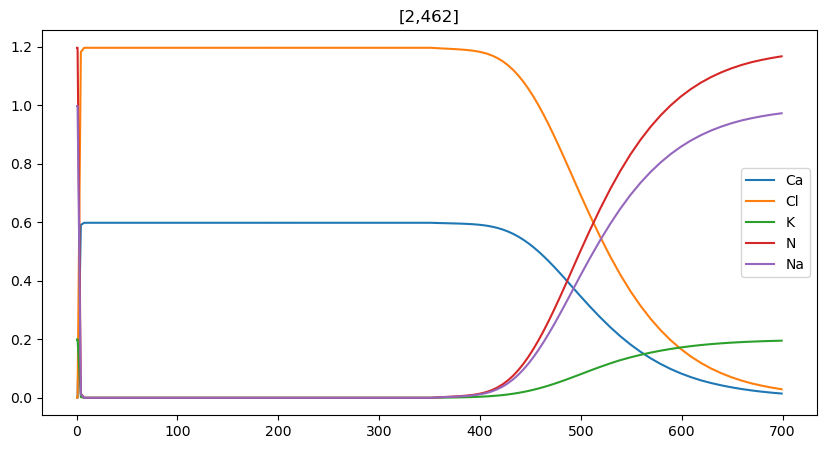

In [97]:
k = wel_lay  # layer index
cnum = wel_cellnum  # cell number
for c in range(len(component_name_l)):
    if component_name_l[c] in components_to_plot:
        fig = plt.figure(num=101, figsize=(10, 5))
        plt.plot(times_c[c], conc[c][:, k, 0, cnum], label=component_name_l[c])
        plt.title("[" + str(k) + "," + str(cnum) + "]")
        plt.legend()

In [98]:
# Get Concentration Values
c = -1
time = 5
layer = 2
cell_num = wel_cellnum + 20
print(component_name_l[c], cell_num)
conc[c][0:time, layer, 0, cell_num]

Na 482


array([0.99703982, 0.99703982, 0.99703981, 0.99703982, 0.99703984])

### Conc Cross Sections

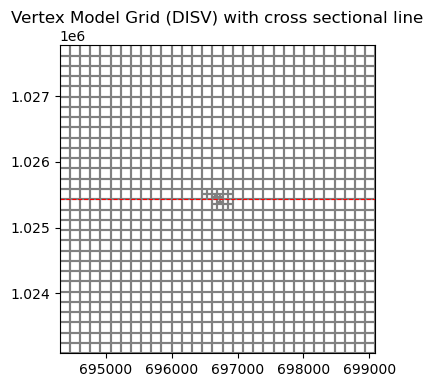

In [99]:
# xsection
# to plot a cross section with disv, you have to make a line to plot along

line = np.array([(694298, 1025429), (6999092, 1025429)])
# creates a plot showing where the line is on the grid to make the cross section plot
fig = plt.figure(figsize=(24, 4))
ax = fig.add_subplot(1, 1, 1, aspect="auto")
ax.set_title("Vertex Model Grid (DISV) with cross sectional line")
# ax.set_xlim(0,0.08)
# ax.set_ylim(0,1.)
# use PlotMapView to plot a DISV (vertex) model
mapview = flopy.plot.PlotMapView(gwf, layer=1)  # ,extent=(0,0.08,0,1.))
# mapview.plot_bc("WEL-1")
# mapview.plot_bc("CHD-1")
linecollection = mapview.plot_grid()
# plot the line over the model grid
lc = plt.plot(line.T[0], line.T[1], "r--", lw=0.8)
plt.show()

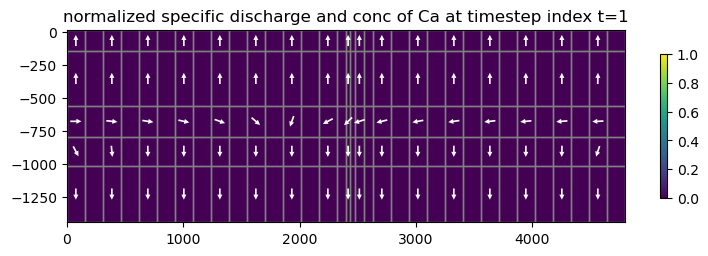

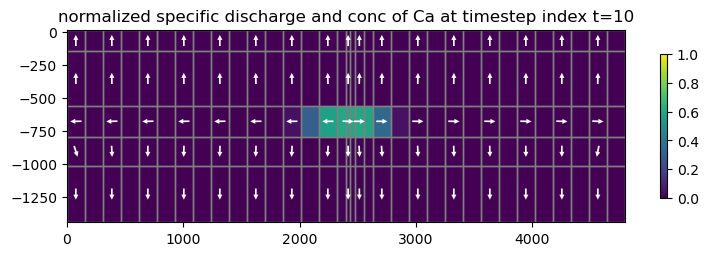

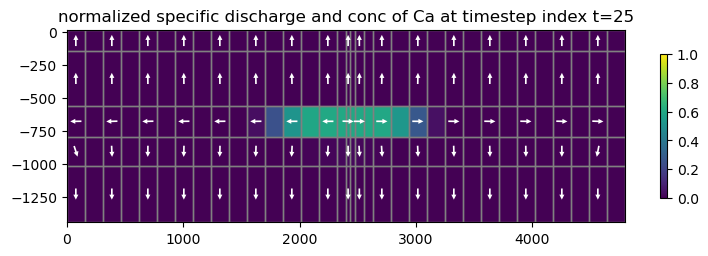

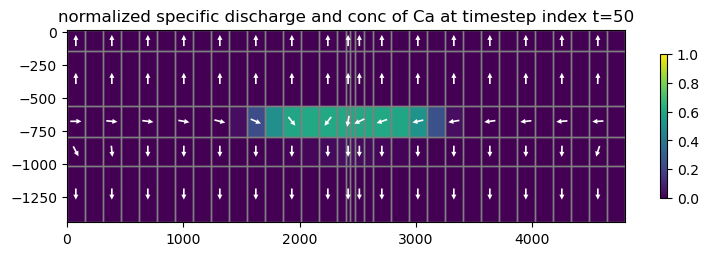

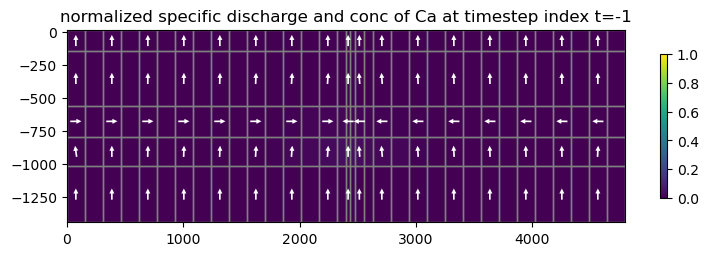

In [100]:
# creates a cross section along the line specified above for each timestep in t_l
s = 4  # solute index for Cl
t_l = [1, 10, 25, 50, -1]  # list of timestep index (NOT actual time/days)
normalize = True
if normalize == True:
    scale = 50
else:
    scale = 100
for t in t_l:
    qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(
        spdis[t], gwf, head=head[t]
    )
    fig = plt.figure(figsize=(9, 2.5))
    ax = fig.add_subplot(1, 1, 1)
    if normalize == True:
        ax.set_title(
            "normalized specific discharge and conc of "
            + component_name_l[s]
            + " at timestep index t="
            + str(t)
        )
    else:
        ax.set_title(
            "specific discharge and conc of "
            + component_name_l[s]
            + " at timestep index t="
            + str(t)
        )
    xsect = flopy.plot.PlotCrossSection(model=gwf, line={"line": line})
    patch_collection = xsect.plot_array(conc[s][t, :, :, :], vmin=0.0, vmax=1.0)
    line_collection = xsect.plot_grid()
    quiver = xsect.plot_vector(
        qx,
        qy,
        qz,
        head=head,
        hstep=2,
        normalize=normalize,
        color="white",
        scale=scale,  # changes arrow length
        width=0.003,
        headwidth=3,
        headlength=3,
        headaxislength=3,
        zorder=10,
    )
    cb = plt.colorbar(patch_collection, shrink=0.75)
    ## TODO: add a legend for the quiver to relate to spdis magnitude when noralized = False..?

### Conc Map View

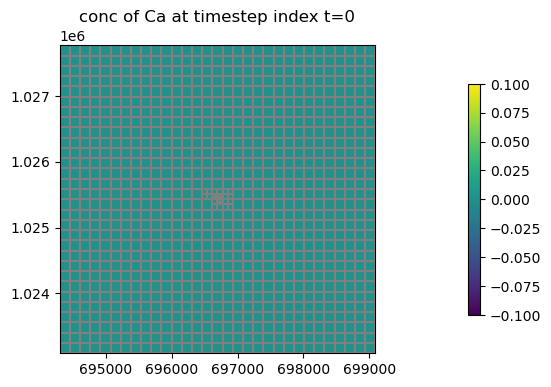

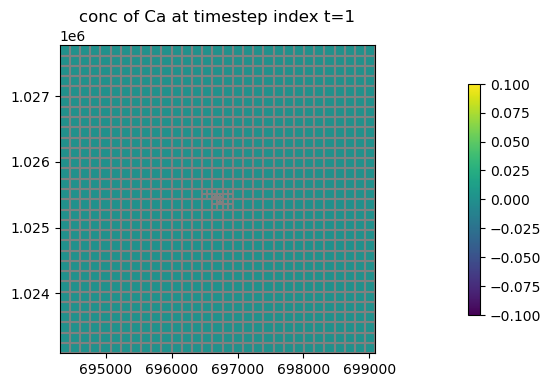

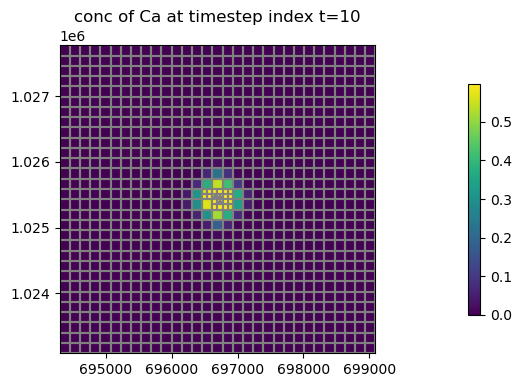

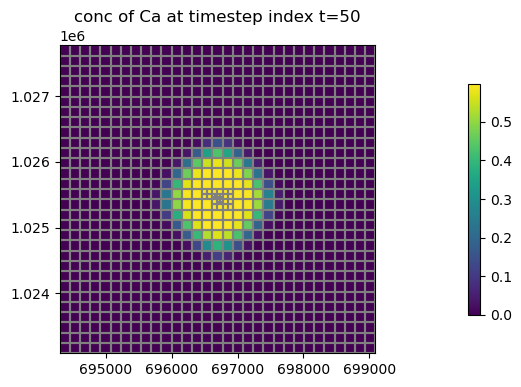

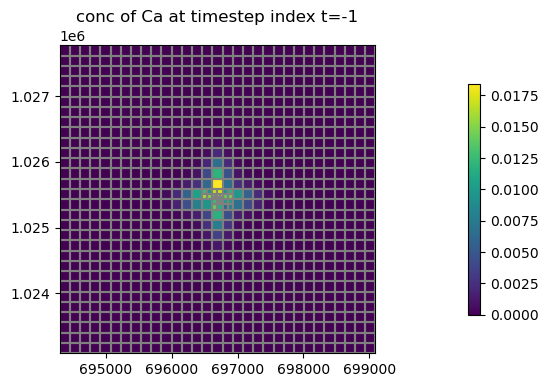

In [101]:
s = 4  # solute index for Ca
t_l = [0, 1, 10, 50, -1]  # list of timestep index (NOT actual time/days)
for t in t_l:
    fig = plt.figure(figsize=(24, 4))
    ax = fig.add_subplot(1, 1, 1, aspect="auto")
    ax.set_title("conc of " + component_name_l[s] + " at timestep index t=" + str(t))
    mapview = flopy.plot.PlotMapView(gwf, layer=2)  # ,extent=(0,0.08,0,1.))
    patch_collection = mapview.plot_array(conc[s][t, :, :, :])  # ,vmin=0., vmax=0.2)
    linecollection = mapview.plot_grid()
    cb = plt.colorbar(patch_collection, shrink=0.75)

# Reactive Transport Simulation
Using MF6RTM

In [102]:
%%time
# Run the model using this wrapper function for `mf6rtm.solve(model.wd)`
reaction_model.run(nthread=4, min_concentration=0.0)

Running mf6rtm
Using libmf6 found in model directory: libmf6.dylib
Processing initial chemistry configuration
Truncating concentrations at 0.00e+00
Starting Solution at 2026-05-11 17:26:16
Transport       | Stress period:  1     | Time step:      1          | Completed in :  0 min   4.53e-05 sec


          Estimated efficiency of chemistry without communication: 96.6905
          Cells shifted between threads     0
          Time rebalancing load             6.10352e-05
          Estimated efficiency of chemistry without communication: 80.4828


Reactions       | Stress period:  1     | Time step:      1          | Completed in :  0 min   1.47e-03 sec
Transport       | Stress period:  1     | Time step:      2          | Completed in :  0 min   5.08e-05 sec
Reactions       | Stress period:  1     | Time step:      2          | Completed in :  0 min   1.55e-03 sec


          Cells shifted between threads     422
          Time rebalancing load             0.00696802


Transport       | Stress period:  2     | Time step:      1          | Completed in :  0 min   2.12e-04 sec
  [Ca] 659 cell(s) below min_concentration (min=-3.82e-05); clipping to 0.00e+00
  [Cl] 406 cell(s) below min_concentration (min=-1.03e-05); clipping to 0.00e+00
Reactions       | Stress period:  2     | Time step:      1          | Completed in :  0 min   2.09e-03 sec


...

Transport       | Stress period:  21    | Time step:      19         | Completed in :  0 min   4.12e-05 sec
Reactions       | Stress period:  21    | Time step:      19         | Completed in :  0 min   1.69e-03 sec


          Cells shifted between threads     0
          Time rebalancing load             5.29289e-05
          Estimated efficiency of chemistry without communication: 99.2533


Transport       | Stress period:  21    | Time step:      20         | Completed in :  0 min   4.36e-05 sec
Reactions       | Stress period:  21    | Time step:      20         | Completed in :  0 min   1.70e-03 sec

Transport converged successfully without any fails

.................,,,,,,,,,,,.,,.......,,,,,,,.,,,,,,,,,,,,,,,,,,,,....
................,,,,,,,,,,,.,,,,......,,,,,,..,,,,,,,,,,...,,,,,,,....
...........,,,,,.,,,,,,,,,,.,,,,.....,..,,,,.,,,,,,.....,,,,,,,.......
.............,,,,,,,,,,,,,,,,,,..,.....,,...,,,,.....,,,,,,,,,,.......
...............,,,,,,,,,,,,,,,,,,,,.,,,,...,,,,,..,,,,,,,,,,,.........
....................,,,,,,,,,,,,,,,,,,,,,,,,,,,.......................
.....................,,,,,,,,,,,,,,,,,,,,,,,,.........................
.....................,,..??????.............??????...................,
......................????????????....????????????...................,
....................???????????????,.?????????????...................,
...................??

          Cells shifted between threads     0
          Time rebalancing load             4.3869e-05


True

Run times:
- 10% faster than grid 1
- 1.124 mins for phreeqcrm v0.17 where nthreads = 1
- 0.628 mins for phreeqcrm v0.17 where nthreads = 4
- 0.61539 mins where nthreads = 4, min_concentration = 0.0

## Visualize MF6RTM Results

Compare sim with and without reactions

In [103]:
# read in mf6 conc results
sim_rxn = flopy.mf6.MFSimulation.load(
    sim_ws=sim_ws,
    exe_name=mf6_exe,  #'mf6',
    verbosity_level=0,
)
conc_rxn = utils.get_concentrations(sim_rxn, component_name_l)
times_c_rxn = utils.get_times_c(sim_rxn, component_name_l)

In [104]:
# read in phreeqc results 
sout_df = pd.read_csv(
    sim_ws / 'sout.csv', 
    sep = ',', 
    skipinitialspace=True, 
    index_col=[0],
)
sout_df.info()
sout_df

<class 'pandas.core.frame.DataFrame'>
Index: 593340 entries, 0.5 to 709.0
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   cell    593340 non-null  float64
 1   Na      593340 non-null  float64
 2   Ca      593340 non-null  float64
 3   K       593340 non-null  float64
 4   Cl      593340 non-null  float64
dtypes: float64(5)
memory usage: 27.2 MB


,cell,Na,Ca,K,Cl
time_d,,,,,
0.5,0.0,0.001,0.0,0.0002,0.0
0.5,1.0,0.001,0.0,0.0002,0.0
0.5,2.0,0.001,0.0,0.0002,0.0
0.5,3.0,0.001,0.0,0.0002,0.0
0.5,4.0,0.001,0.0,0.0002,0.0
...,...,...,...,...,...
709.0,4780.0,0.001,0.0,0.0002,0.0
709.0,4781.0,0.001,0.0,0.0002,0.0
709.0,4782.0,0.001,0.0,0.0002,0.0


In [105]:
component_name_l

['H2O', 'H', 'O', 'Charge', 'Ca', 'Cl', 'K', 'N', 'Na']

In [106]:
list_offset = len(component_name_l) - len(components_to_plot)
list_offset

4

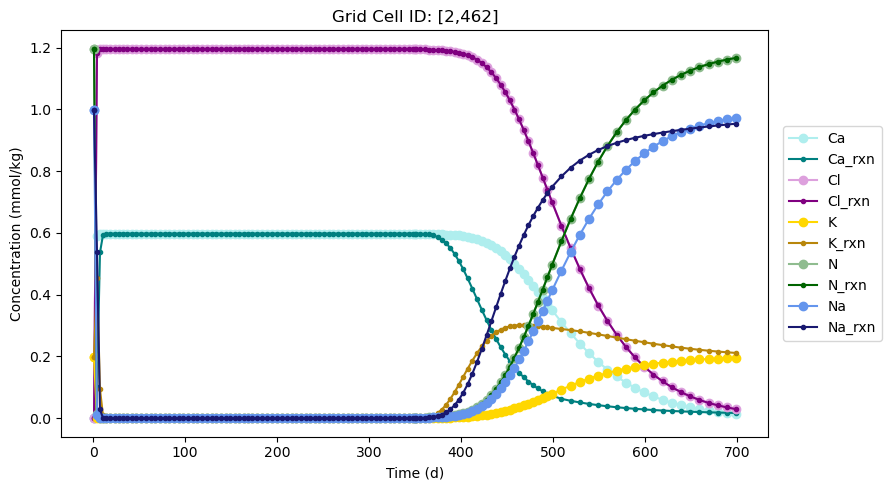

In [107]:
# plot mf6 transport only, mf6 conc with rxn, and phreeqc
k = 2 #wel_lay  # layer index
cnum = wel_cellnum  # cell number
colors_c     = ['paleturquoise','plum','gold','darkseagreen','cornflowerblue'] 
colors_c_rxn = ['teal','purple','darkgoldenrod','darkgreen','midnightblue']
f = 101 # Figure Number
for c in range(len(component_name_l)):
    if component_name_l[c] in components_to_plot:
        # print(component_name_l[c])
        fig = plt.figure(num=f, figsize=(9, 5))
        plt.plot(times_c[c], conc[c][:, k, 0, cnum], color=colors_c[c-list_offset],label=component_name_l[c],marker='.',markersize=12)
        plt.plot(times_c_rxn[c], conc_rxn[c][:, k, 0, cnum], color=colors_c_rxn[c-list_offset], label=component_name_l[c]+'_rxn',marker='.')
        plt.title("Grid Cell ID: [" + str(k) + "," + str(cnum) + "]")
        leg = plt.legend(loc='center right', bbox_to_anchor=(1.17, 0.5))
plt.xlabel('Time (d)')
plt.ylabel('Concentration (mmol/kg)')
plt.tight_layout()
plt.show()

In [108]:
component_name_l

['H2O', 'H', 'O', 'Charge', 'Ca', 'Cl', 'K', 'N', 'Na']

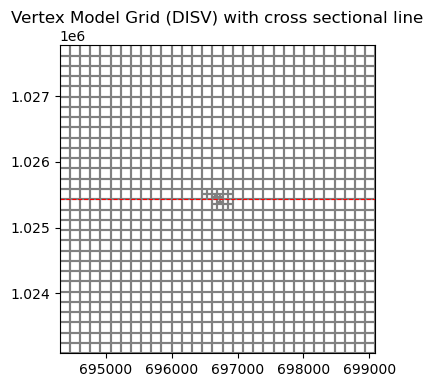

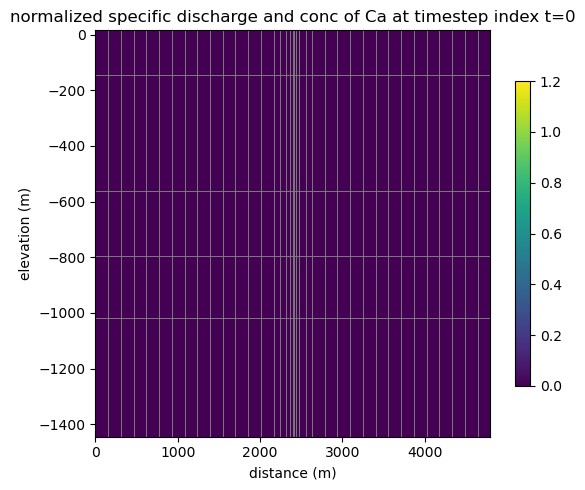

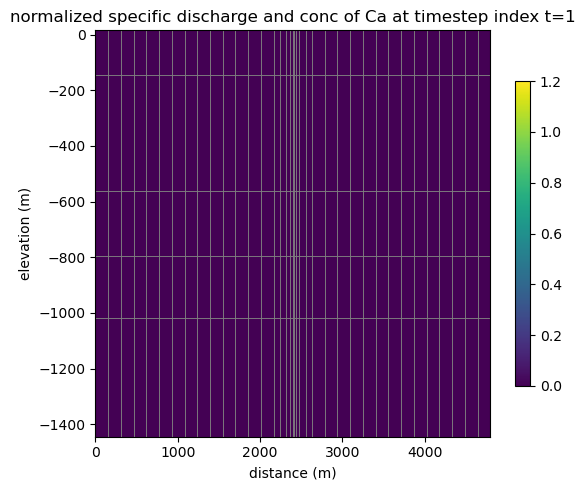

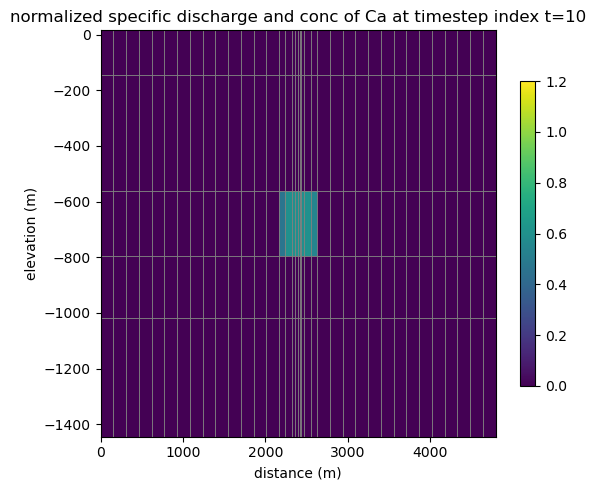

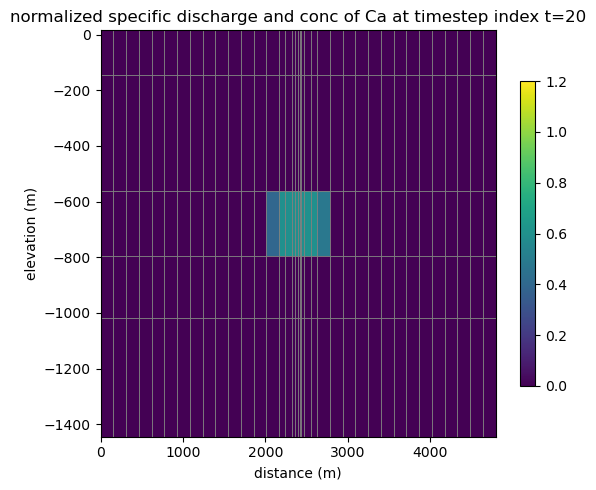

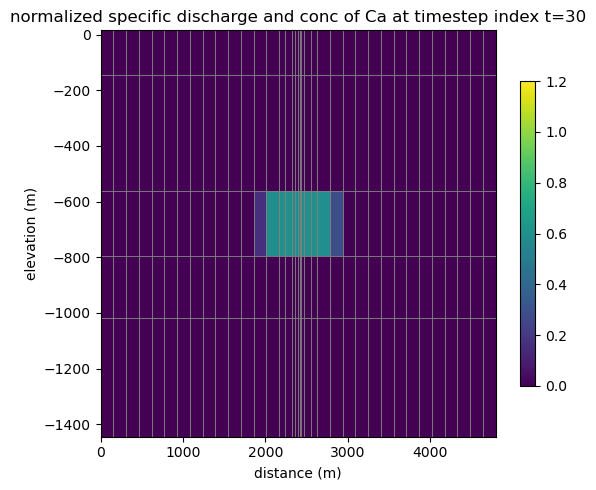

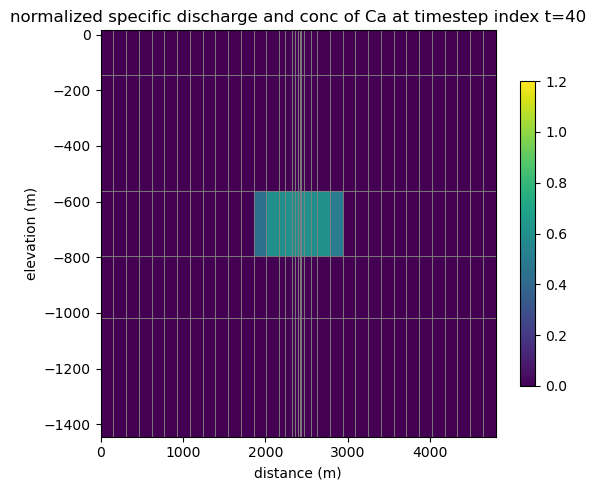

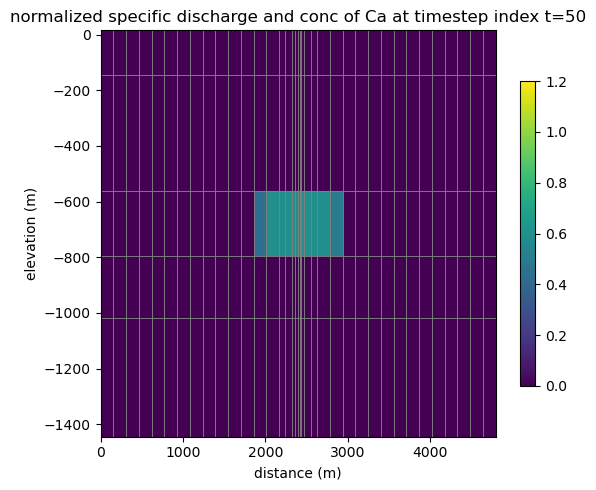

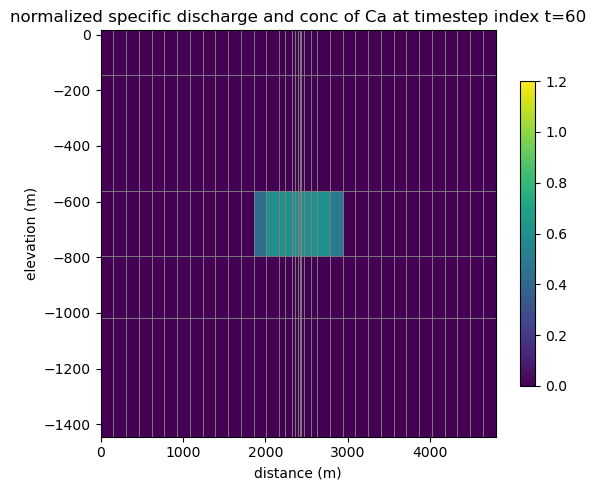

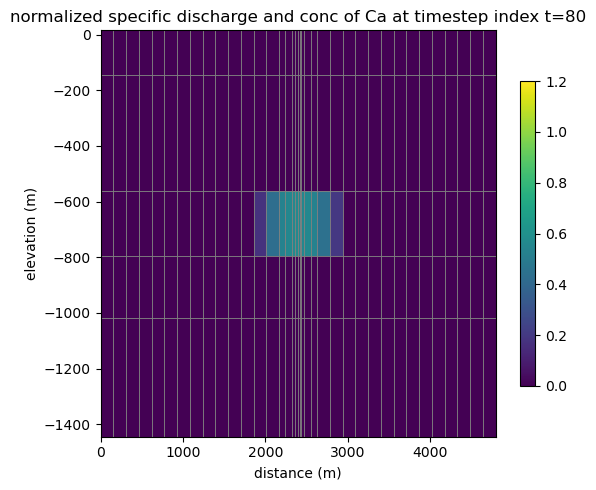

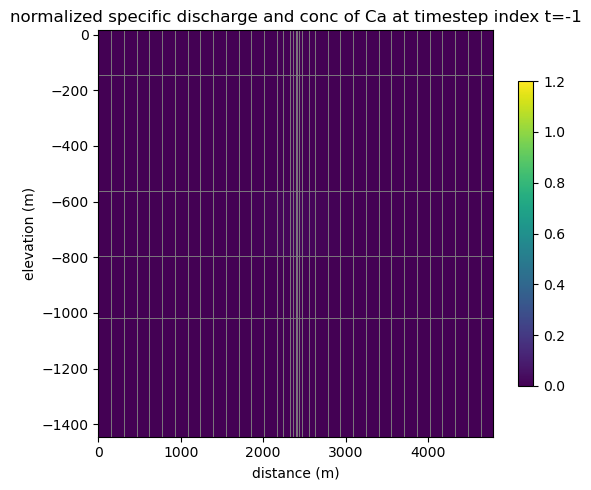

In [109]:

################################################################################
### Plot cross section (xsect) of concentration of MF6RTM with rxn results
################################################################################

# OPTIONS # 
plot_bcs = False # if True, plots boundary conditions for wel and chd package
normalize = True # if True, specific discharge is normalized and only shows direction
plot_spdis = False # if True, plots specific discharge on cross section
# component_name_l = ['H', 'O', 'Charge', 'Ca', 'Cl', 'K', 'N', 'Na']
s = component_name_l.index("Ca")  # solute index for Ca
t_l = [0, 1,10,20, 30, 40, 50, 60, 80, -1]  # list of timestep index (NOT actual time/days)
# OPTIONS #

# to plot a cross section with disv, you have to make a line to plot along
line = np.array([(694298, 1025435), (6999092, 1025435)]) # goes through wel cellID 496
# creates a plot showing where the line is on the grid to make the cross section plot
fig = plt.figure(num=f,figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1, aspect="auto")
ax.set_title("Vertex Model Grid (DISV) with cross sectional line")
# use PlotMapView to plot a DISV (vertex) model
mapview = flopy.plot.PlotMapView(gwf, layer=1)  # ,extent=(0,0.08,0,1.))
if plot_bcs == True:
    mapview.plot_bc("WEL-1")
    mapview.plot_bc("CHD-1")
linecollection = mapview.plot_grid()
# plot the line over the model grid
lc = plt.plot(line.T[0], line.T[1], "r--", lw=0.8)
plt.show()
f = f + 1

# creates a cross section along the line specified above for each timestep in t_l
# reads concentration data from modflow6 output files for MF6RTM simulation
sim = flopy.mf6.MFSimulation.load(
    sim_ws=sim_ws,
    exe_name=mf6_exe,
    verbosity_level=0,
)
conc = utils.get_concentrations(sim, component_name_l)
times_c = utils.get_times_c(sim, component_name_l)

if normalize == True:
    scale = 50
else:
    scale = 100
for t in t_l:
    qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(
        spdis[t], gwf, head=head[t]
    )
    fig = plt.figure(num = f,figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1)
    if normalize == True:
        ax.set_title(
            "normalized specific discharge and conc of "
            + component_name_l[s]
            + " at timestep index t="
            + str(t)
        )
    else:
        ax.set_title(
            "specific discharge and conc of "
            + component_name_l[s]
            + " at timestep index t="
            + str(t)
        )
    xsect = flopy.plot.PlotCrossSection(model=gwf, line={"line": line})
    patch_collection = xsect.plot_array(conc[s][t, :, :, :], vmin=0.0, vmax=1.2)
    line_collection = xsect.plot_grid(linewidth=0.5)
    if plot_spdis == True:
        quiver = xsect.plot_vector(
            qx,
            qy,
            qz,
            head=head,
            hstep=2,
            normalize=normalize,
            color="white",
            scale=scale,  # changes arrow length
            width=0.003,
            headwidth=3,
            headlength=3,
            headaxislength=3,
            zorder=10,
        )
    cb = plt.colorbar(patch_collection, shrink=0.75)
    ## TODO: add a legend for the quiver to relate to spdis magnitude when noralized = False..?
    plt.xlabel('distance (m)')
    plt.ylabel('elevation (m)')
    plt.tight_layout()
    plt.show()
    f = f + 1

# END